In [1]:
!pip install transformers datasets scikit-learn pandas

In [2]:
from google.colab import files
uploaded = files.upload()

Saving test.csv to test.csv
Saving train.csv to train.csv


In [3]:
import pandas as pd

train_df = pd.read_csv("train.csv", encoding='latin1')
test_df = pd.read_csv("test.csv", encoding='latin1')



In [4]:
print(train_df.columns)

Index(['textID', 'text', 'selected_text', 'sentiment', 'Time of Tweet',
       'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)',
       'Density (P/Km²)'],
      dtype='object')


In [5]:
train_df['sentiment'].value_counts()

,count
sentiment,
neutral,11118
positive,8582
negative,7781


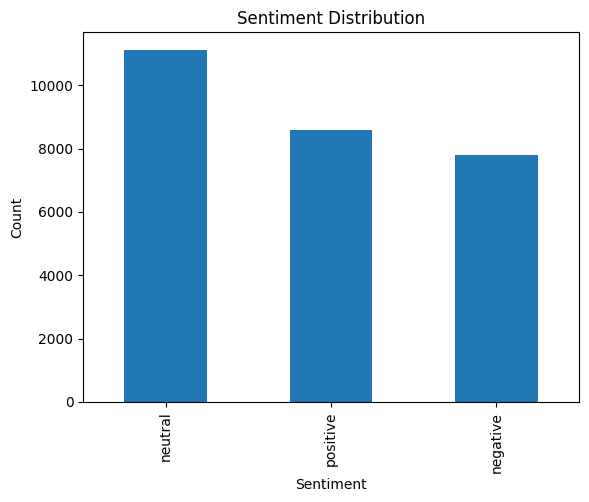

In [6]:
import matplotlib.pyplot as plt

train_df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

Observations:
- The dataset is moderately imbalanced.
- Neutral class has the highest number of samples.
- Negative class has the least number of samples.
- This imbalance may cause the model to perform better on the neutral class.
- Special attention may be needed to ensure balanced performance across all classes.

In [7]:
# label encoding
label_map = {"negative": 0, "neutral": 1, "positive": 2}

train_df["label"] = train_df["sentiment"].map(label_map)
test_df["label"] = test_df["sentiment"].map(label_map)

In [8]:
train_df = train_df.dropna(subset=["text", "sentiment"])
test_df = test_df.dropna(subset=["text", "sentiment"])

In [9]:
train_df["text"] = train_df["text"].astype(str)
test_df["text"] = test_df["text"].astype(str)

In [10]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df["text"].tolist(),
    train_df["label"].tolist(),
    test_size=0.1,
    random_state=42
)

test_texts = test_df["text"].tolist()
test_labels = test_df["label"].tolist()

In [11]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [12]:
import torch
from torch.utils.data import Dataset

class SentimentDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=128
        )
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [13]:
train_dataset = SentimentDataset(train_texts, train_labels)
val_dataset = SentimentDataset(val_texts, val_labels)
test_dataset = SentimentDataset(test_texts, test_labels)

In [14]:
train_dataset[0]

{'input_ids': tensor([  101,  2204,  5955,  1012,  1012,  1012,  1012,  1012,  2021,  2059,
          2026,  5795,  2052,  3191,  1012,  1012,  1012,  1012,  3599,  2054,
         10047,  4011,  2000,  2079,  1998,  2052,  2113,  2073,  1045,  2001,
          2007,  1996,  2622,   102,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0]),
 'token_type_ids': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0,

In [15]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [16]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_dir="./logs",
    load_best_model_at_end=True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [17]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [18]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [19]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.577060,0.555733,0.781295,0.779918,0.785340,0.781295
2,0.434009,0.637037,0.787118,0.786975,0.786867,0.787118
3,0.327737,0.820292,0.790393,0.789976,0.789824,0.790393


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=9276, training_loss=0.45908266472991244, metrics={'train_runtime': 1709.611, 'train_samples_per_second': 43.399, 'train_steps_per_second': 5.426, 'total_flos': 4194171768734640.0, 'train_loss': 0.45908266472991244, 'epoch': 3.0})

The training loss decreases steadily, indicating that the model is effectively learning from the data. However, the validation loss increases after the first epoch, suggesting the onset of overfitting. Despite this, the model achieves an accuracy of approximately 79% with a similar F1 score, indicating balanced and reliable performance across classes. The results demonstrate that the BERT model successfully captures contextual relationships in text, although early stopping could further improve generalization.

In [23]:
import torch
from torch.utils.data import DataLoader

# Create dataloader
test_loader = DataLoader(test_dataset, batch_size=8)

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        inputs = {
            "input_ids": batch["input_ids"].to(model.device),
            "attention_mask": batch["attention_mask"].to(model.device)
        }
        labels = batch["labels"].numpy()

        outputs = model(**inputs)
        logits = outputs.logits

        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels)

In [24]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds,
                            target_names=["negative", "neutral", "positive"]))

              precision    recall  f1-score   support

    negative       0.72      0.86      0.78      1001
     neutral       0.79      0.69      0.73      1430
    positive       0.84      0.83      0.84      1103

    accuracy                           0.78      3534
   macro avg       0.78      0.79      0.78      3534
weighted avg       0.78      0.78      0.78      3534



The model achieves an overall accuracy of 78%, indicating good performance. The positive class shows the highest precision and recall, suggesting that the model effectively identifies positive sentiment. The negative class has high recall but lower precision, indicating that while most negative samples are detected, some misclassifications occur. The neutral class has the lowest recall, making it the most challenging to classify due to its ambiguous nature. Overall, the model demonstrates balanced performance across classes, confirming the effectiveness of BERT in capturing contextual information.

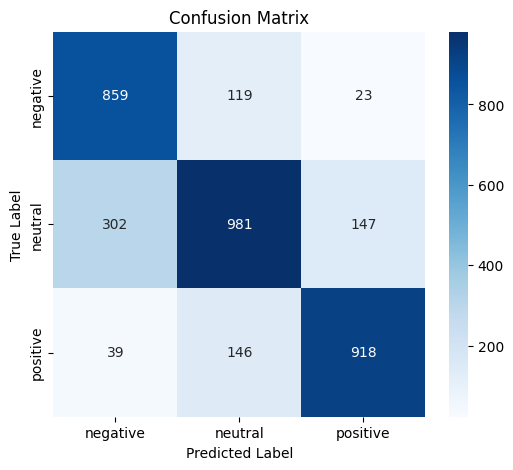

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["negative", "neutral", "positive"],
            yticklabels=["negative", "neutral", "positive"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Conclusion:
- The BERT-based sentiment classification model achieved an accuracy of approximately 78%, demonstrating strong performance on the dataset.
- The model effectively leveraged transfer learning to capture contextual relationships in text.
- While the positive class was classified most accurately, the neutral class proved more challenging due to its ambiguous nature.
- The training process showed slight overfitting, as indicated by increasing validation loss in later epochs.
- Overall, the model demonstrates balanced and reliable performance, highlighting the effectiveness of transformer-based approaches for text classification tasks.